# 📘 Notebook 02: Sinusoidal Positional Embeddings

In Transformers, positional embeddings are added to token embeddings to help the model understand word order.  
This notebook implements the sinusoidal method from the paper *"Attention Is All You Need"*.

---

## 🧠 Key Idea

Each position (0, 1, 2, ...) in a sentence gets a **fixed vector** based on sine and cosine functions at different frequencies.

This has two benefits:
- Doesn’t require training (no extra parameters)
- Nearby positions have similar vectors

---

In [1]:
import torch, math

def get_sinusoidal_positional_embeddings(seq_len, embedding_dim) :
    # Initialize a matrix of shape (seq_len, embedding_dim)
    pe = torch.zeros(seq_len, embedding_dim)

    # Create a tensor with positions [0, 1, 2, .... seq_len - 1]
    position = torch.arange(0, seq_len).unsqueeze(1)

    # Compute denominator term : 10000^(2i/d)
    div_term = torch.exp(torch.arange(0, embedding_dim, 2) * (-math.log(10000.0)/embedding_dim))

    # Apply sin to even indices
    pe[:, 0::2] = torch.sin(position * div_term)

    # Apply cos to odd indices 
    pe[:, 1::2] = torch.cos(position * div_term)

    return pe

In [2]:
# Parameters
seq_len = 10
embedding_dim = 16

# Get positional embeddings
pos_embeddings = get_sinusoidal_positional_embeddings(seq_len, embedding_dim)

print(f"Shape : {pos_embeddings.shape}")
print(f"Position 0 vector : \n{pos_embeddings[0]}")
print(f"Position 1 vector : \n{pos_embeddings[1]}")

Shape : torch.Size([10, 16])
Position 0 vector : 
tensor([0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.])
Position 1 vector : 
tensor([8.4147e-01, 5.4030e-01, 3.1098e-01, 9.5042e-01, 9.9833e-02, 9.9500e-01,
        3.1618e-02, 9.9950e-01, 9.9998e-03, 9.9995e-01, 3.1623e-03, 9.9999e-01,
        1.0000e-03, 1.0000e+00, 3.1623e-04, 1.0000e+00])


## Visulaize as Heatmap

Text(0, 0.5, 'Token Positions')

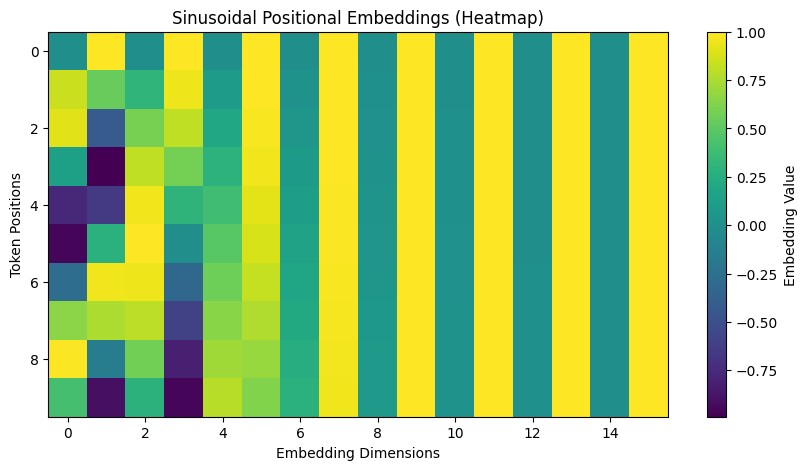

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.imshow(pos_embeddings.numpy(), aspect= "auto", cmap= "viridis")
plt.colorbar(label = "Embedding Value")
plt.title("Sinusoidal Positional Embeddings (Heatmap)")
plt.xlabel("Embedding Dimensions")
plt.ylabel("Token Positions")


## ✅ Summary

- Positional embeddings help encode **token order**.
- Sinusoidal approach is:
  - Deterministic
  - Smooth
  - Parameter-free (no training needed)
- Often used in small or classic models, or combined with learned embeddings.

---

🔜 Next notebook: **Learned Positional Embeddings** — how models can learn position vectors during training!